In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import tensorflow_datasets as tdfs

In [ ]:
dataset, info = tdfs.load('cats_vs_dogs', with_info=True, as_supervised=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.C037TF_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.


In [ ]:
dataset

{Split('train'): <_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>}

In [ ]:
info

tfds.core.DatasetInfo(
    name='cats_vs_dogs',
    full_name='cats_vs_dogs/4.0.1',
    description="""
    A large set of images of cats and dogs. There are 1738 corrupted images that are dropped.
    """,
    homepage='https://www.microsoft.com/en-us/download/details.aspx?id=54765',
    data_dir='/root/tensorflow_datasets/cats_vs_dogs/4.0.1',
    file_format=tfrecord,
    download_size=786.67 MiB,
    dataset_size=1.04 GiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'image/filename': Text(shape=(), dtype=string),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'train': <SplitInfo num_examples=23262, num_shards=16>,
    },
    citation="""@Inproceedings (Conference){asirra-a-captcha-that-exploits-interest-aligned-manual-image-categorization,
    author = {Elson, Jeremy and Douceur, Jo

In [ ]:
train_data = dataset['train'].take(2000)
val_data = dataset['train'].skip(2000).take(1000)

def preprocess(image, label):
  image = tf.image.resize(image, (150,150))
  image = image / 255.0
  return image, label

train_data = train_data.map(preprocess).batch(32)
val_data = val_data.map(preprocess).batch(32)

In [ ]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
history = model.fit(train_data, epochs=5, validation_data=val_data)

Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 117s 2s/step - accuracy: 0.5056 - loss: 0.7211 - val_accuracy: 0.5800 - val_loss: 0.6764
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 113s 2s/step - accuracy: 0.6055 - loss: 0.6609 - val_accuracy: 0.6460 - val_loss: 0.6203
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 115s 2s/step - accuracy: 0.6798 - loss: 0.5938 - val_accuracy: 0.7000 - val_loss: 0.6016
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.7401 - loss: 0.5189 - val_accuracy: 0.7310 - val_loss: 0.5852
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 109s 2s/step - accuracy: 0.7881 - loss: 0.4285 - val_accuracy: 0.7160 - val_loss: 0.6544


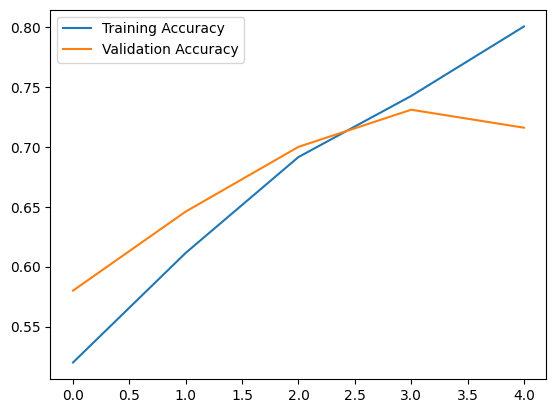

In [ ]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

In [ ]:
img = image.load_img('Cat-on-couch.jpg', target_size=(150,150))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis = 0)

In [ ]:
prediction = model.predict(img_array)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


In [ ]:
prediction

array([[0.6174447]], dtype=float32)

In [ ]:
if prediction[0][0]>0.5:
  print('This looks like a dog')
else:
  print('This looks like a cat')

This looks like a dog
